In [11]:
# PACKAGE INSTALLATION

!pip3 install scikit-learn pandas matplotlib seaborn

In [2]:
# IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

import numpy as np


In [3]:
# DATA LOADING

# load built-in UCI Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()

# feature matrix and label vector
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("X shape:", X.shape) # expected (569, 30)
print("y shape:", y.shape) # expected (569,)
print("target names:", data.target_names)
X.head()

X shape: (569, 30)
y shape: (569,)
target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Class Distribution:
 target
1    357
0    212
Name: count, dtype: int64


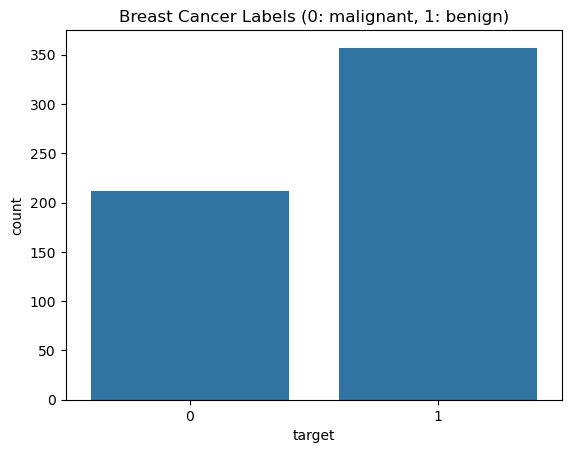

In [4]:
# EXPLORATORY DATA ANALYSIS

# confirm class balance
print("Class Distribution:\n", y.value_counts())

# plot counts visually
sns.countplot(x=y)
plt.title("Breast Cancer Labels (0: malignant, 1: benign)")
plt.show()

In [5]:
# DATA PREPROCESSING

# stratified split preserves class ratio in train/test
# splitting into 80% training and 20% for testing
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# standardize features (mean=0, std=1)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("x_train:", x_train.shape, "x_test:", x_test.shape)

x_train: (455, 30) x_test: (114, 30)


In [6]:
# MODEL TRAINING

# RBF SVM with default regularization parameters
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# training
model.fit(x_train, y_train)

# debug: check training accuracy
print("training complete")

training complete


In [ ]:
# EVALUATION

# predict on test set
preds = model.predict(x_test)

# report accuracy, confusion matrix, classification report
print("Accuracy:", accuracy_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("Classification Report:\n", classification_report(y_test, preds))

Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



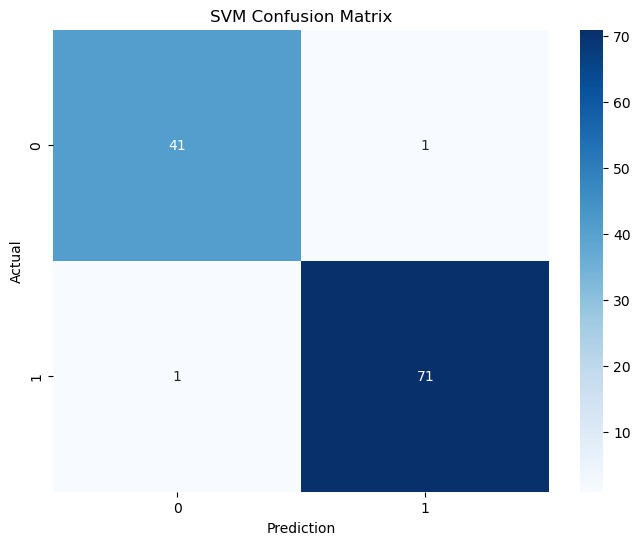

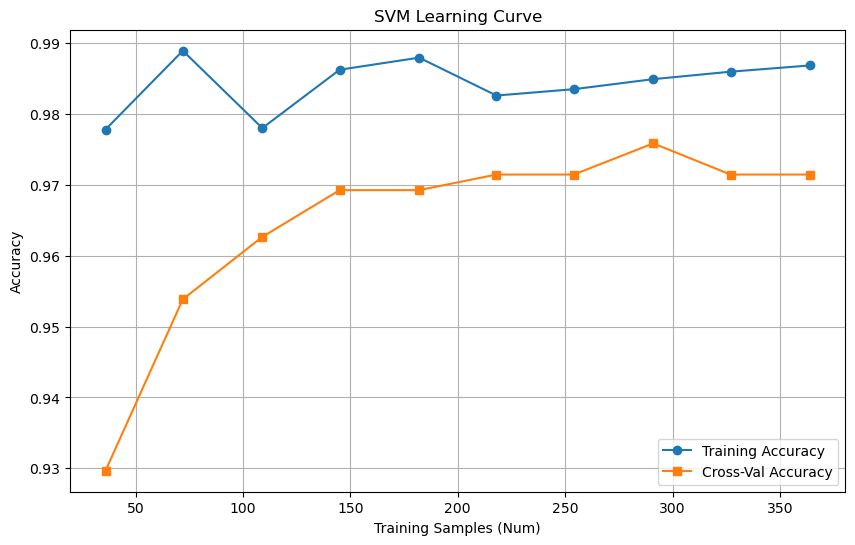

In [ ]:
# VISUALIZATION

# confusion matrix heatmap
plt.figure(figsize= (8,6))
sns.heatmap(confusion_matrix(y_test, preds), annot = True, fmt = 'd', cmap = 'Blues')

# labels and title
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

# grid and show
plt.show()

#computing learning curve
train_size, train_score, test_score = learning_curve(model,  x_train, y_train, cv = 5, scoring = 'accuracy', train_sizes = np.linspace(.10, 1.0, 10))

#means and std
train_m = np.mean(train_score, axis = 1)
test_m = np.mean(test_score, axis = 1)

# plotting learning curve
plt.figure(figsize = (10,6))
plt.plot(train_size, train_m, label = 'Training Accuracy', marker ='o')
plt.plot(train_size, test_m, label = 'Cross-Val Accuracy', marker ='s')
plt.xlabel("Training Samples (Num)")
plt.ylabel("Accuracy")
plt.title("SVM Learning Curve")

# grid and legend
plt.grid(True)
plt.legend()

# show plot
plt.show()

Cross-validation Results
Runs               : 50
Mean Accuracy      : 0.9149
Standard Deviation : 0.0203
Minimum Accuracy   : 0.8684
Maximum Accuracy   : 0.9649


Text(0, 0.5, 'Frequency')

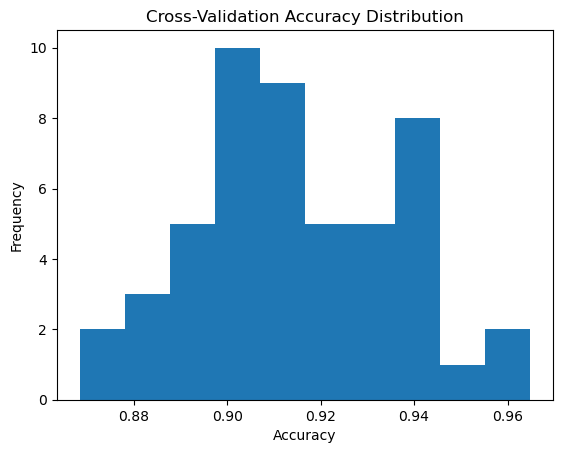

In [16]:
# CROSS-VALIDATION

# setup repeated stratified k-fold (5x10)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# run cross-validation
scores = cross_val_score(model, X, y, cv=rskf, scoring='accuracy', n_jobs=-1)

# compute stats
mean_score = scores.mean()
std_score = scores.std()
min_score = scores.min()
max_score = scores.max()

# formatted output
print("Cross-validation Results")
print(f"Runs               : {len(scores)}")
print(f"Mean Accuracy      : {mean_score:.4f}")
print(f"Standard Deviation : {std_score:.4f}")
print(f"Minimum Accuracy   : {min_score:.4f}")
print(f"Maximum Accuracy   : {max_score:.4f}")

# histogram of scores
plt.figure()
plt.hist(scores, bins=10)
plt.title("Cross-Validation Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")


Stratified K-Fold Results
Folds              : 5
Mean Accuracy      : 0.9772
Standard Deviation : 0.0163
Minimum Accuracy   : 0.9474
Maximum Accuracy   : 0.9912


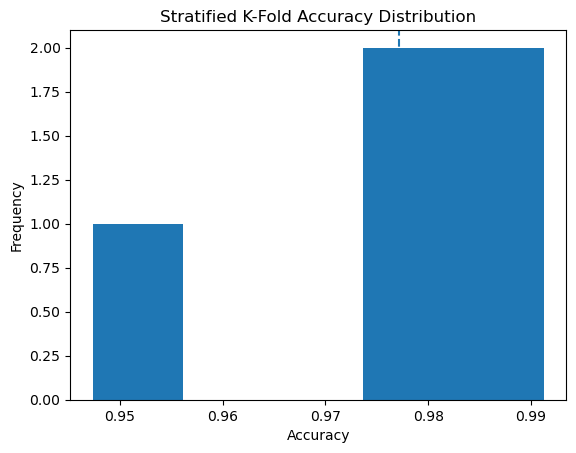

In [17]:
# ALTERNATIVE: MANUAL STRATIFIED K-FOLD

# setup stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = []

# run cv loop
for train_idx, test_idx in skf.split(X, y):
    # split data
    x_tr, x_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # scale per fold
    x_tr = scaler.fit_transform(x_tr)
    x_te = scaler.transform(x_te)

    # train + predict
    model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    model.fit(x_tr, y_tr)
    y_pred = model.predict(x_te)

    acc.append(accuracy_score(y_te, y_pred))

# compute stats
mean_acc = np.mean(acc)
std_acc = np.std(acc)

# formatted output
print("Stratified K-Fold Results")
print(f"Folds              : {len(acc)}")
print(f"Mean Accuracy      : {mean_acc:.4f}")
print(f"Standard Deviation : {std_acc:.4f}")
print(f"Minimum Accuracy   : {min(acc):.4f}")
print(f"Maximum Accuracy   : {max(acc):.4f}")

plt.figure()
plt.hist(acc, bins=5)
plt.axvline(np.mean(acc), linestyle='dashed')
plt.title("Stratified K-Fold Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()